In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("/Users/salehalzahrani/Downloads/Coffee Sales.csv")
df.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Karen Clark,China,Organic Fair Trade,19/02/2022,"$39,199.64",413
1,Daniel Lee,USA,Arabica Dark Roast,16/11/2022,"$5,214.27",152
2,Daniel Lee,China,Robusta Medium,02/10/2023,"$26,553.48",325
3,John Doe,Australia,Breakfast Blend,21/04/2022,"$14,547.43",370
4,Laura Martinez,UK,French Roast,13/04/2023,"$15,270.04",156
5,George Young,Canada,Colombian Supremo,15/10/2022,"$3,371.67",117
6,Laura Martinez,USA,Arabica Dark Roast,13/09/2023,"$8,478.10",103
7,Sarah Taylor,Germany,Espresso Blend,23/09/2023,"$7,127.36",195
8,David Anderson,UK,Espresso Blend,30/05/2023,"$7,945.88",193
9,Betty King,Brazil,Hazelnut Cream,27/10/2023,"$9,648.78",188


In [4]:
df.dtypes

Sales Person       str
Country            str
Product            str
Date               str
Amount             str
Boxes Shipped    int64
dtype: object

In [5]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Amount'] = df['Amount'].replace(r'[\$,]', '', regex=True)
df['Amount'] = pd.to_numeric(df['Amount'])

df.dtypes

Sales Person                str
Country                     str
Product                     str
Date             datetime64[us]
Amount                  float64
Boxes Shipped             int64
dtype: object

In [6]:
df.isna().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

In [7]:
df_missing = df.copy()
df_missing.loc[0:5, 'Amount'] = np.nan
df_missing.isna().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           6
Boxes Shipped    0
dtype: int64

In [8]:
print("Original shape: ",df.shape)
print("After removing some values: ",df_missing.shape)

Original shape:  (200, 6)
After removing some values:  (200, 6)


In [9]:
df_missing.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Karen Clark,China,Organic Fair Trade,2022-02-19,NaN,413
1,Daniel Lee,USA,Arabica Dark Roast,2022-11-16,NaN,152
2,Daniel Lee,China,Robusta Medium,2023-10-02,NaN,325
3,John Doe,Australia,Breakfast Blend,2022-04-21,NaN,370
4,Laura Martinez,UK,French Roast,2023-04-13,NaN,156
5,George Young,Canada,Colombian Supremo,2022-10-15,NaN,117
6,Laura Martinez,USA,Arabica Dark Roast,2023-09-13,8478.10,103
7,Sarah Taylor,Germany,Espresso Blend,2023-09-23,7127.36,195
8,David Anderson,UK,Espresso Blend,2023-05-30,7945.88,193
9,Betty King,Brazil,Hazelnut Cream,2023-10-27,9648.78,188


In [12]:
df_removed = df_missing.dropna()
df_removed.shape

(194, 6)

In [13]:
df_removed.isna().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

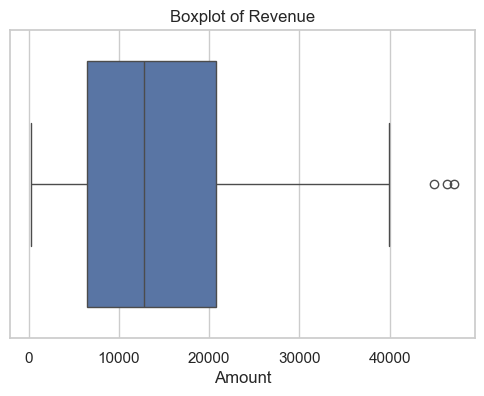

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Amount'])
plt.title("Boxplot of Revenue")
plt.show()

In [15]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Amount'] < lower) | (df['Amount'] > upper)]
outliers.head(15)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
69,John Doe,France,Arabica Dark Roast,2022-10-25,46361.34,471
105,Laura Martinez,India,Hazelnut Cream,2022-07-25,44906.69,483
141,Nancy Allen,China,Organic Fair Trade,2022-04-01,47138.94,477


In [16]:
df_no_outliers = df[(df['Amount'] >= lower) & (df['Amount'] <= upper)]
print("Original shape: ",df.shape)
print("After removing outliers: ",df_no_outliers.shape)

Original shape:  (200, 6)
After removing outliers:  (197, 6)


In [18]:
lower_cap = df['Amount'].quantile(0.05)
upper_cap = df['Amount'].quantile(0.95)

df_capped = df.copy()
df_capped['Amount'] = df_capped['Amount'].clip(lower_cap, upper_cap)

In [ ]:
df[['Amount', 'Boxes Shipped']].head() 

,Amount,Boxes Shipped
0,39199.64,413
1,5214.27,152
2,26553.48,325
3,14547.43,370
4,15270.04,156


In [21]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 4.1 MB/s  0:00:02m 3.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 9.2 MB/s  0:00:029.3 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn]0m 3/4 [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['Amount', 'Boxes Shipped']].copy()

df_scaled[['Amount', 'Boxes Shipped']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Amount,Boxes Shipped
0,0.830685,0.829218
1,0.105908,0.292181
2,0.560991,0.648148
3,0.304948,0.740741
4,0.320359,0.300412


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['Amount', 'Boxes Shipped']].copy()

df_standardized[['Amount', 'Boxes Shipped']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,Amount,Boxes Shipped
0,2.479294,1.410533
1,-0.906228,-0.600936
2,1.219521,0.732337
3,0.023514,1.079142
4,0.095498,-0.570109


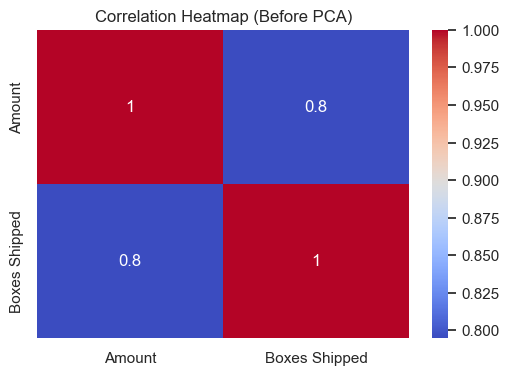

In [24]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['Amount','Boxes Shipped']].corr(), 
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

In [25]:
from sklearn.decomposition import PCA

X = df_standardized[['Amount', 'Boxes Shipped']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.89751108 0.10248892]


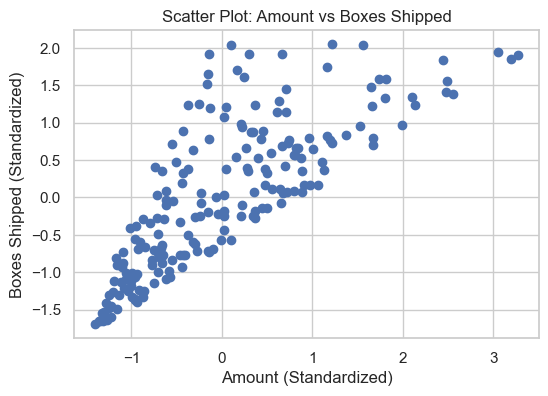

In [27]:
 plt.figure(figsize=(6,4))
 plt.scatter(df_standardized['Amount'], df_standardized['Boxes Shipped'])
 plt.xlabel("Amount (Standardized)")
 plt.ylabel("Boxes Shipped (Standardized)")
 plt.title("Scatter Plot: Amount vs Boxes Shipped")
 plt.show()